In [21]:
###################################################################

# Decay Functions for Euler, RK2, and ODEINT
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def decay_deriv(N,t):
    # The derivative in principle may depend on N and t -- in this
    # case, it only depends on N
    return -(1./tau) * N


def RK2_Solver(N0, tmin, tmax, nts, decay_deriv):
    N_array = np.zeros(nts)                                                     # array to hold number of nuclei
    t_array = np.linspace(tmin, tmax, nts, endpoint=False)                      # array holds the time points 
    dt = t_array[1] - t_array[0]                                                # dt = time step length  
    N_array[0] = N0                                                             # Initial number of nuclei
    for it in range(0, len(t_array)-1 ):                                        # loop over time steps
        t  = t_array[it]                                                        
        N_h = N_array[it] + (dt/2 * decay_deriv(N_array[it], t))                # sub-step 1 for RK2
        N_array[it+1] = N_array[it] + (dt * decay_deriv(N_h, t + dt/2))         # sub-step 2 for RK2
    return t_array, N_array

def Euler_solver(N_initial, tmin, tmax, nts, deriv):
    N = np.zeros(nts+1)
    t = np.linspace(tmin, tmax, nts+1)
    
    # Note: a way of defining dt that is less error-prone
    dt = t[1] - t[0]
    N[0] = N_initial
    for it in range(0,nts):
        N[it+1] = N[it] + dt * deriv(N[it], t[it])
    return t, N

def diffeq_solver_from_scipy(N0, tmin, tmax, nts, decay_deriv):
    t = np.linspace(tmin, tmax, nts, endpoint=False)  
    N = odeint(decay_deriv, N0, t)
    return t, N



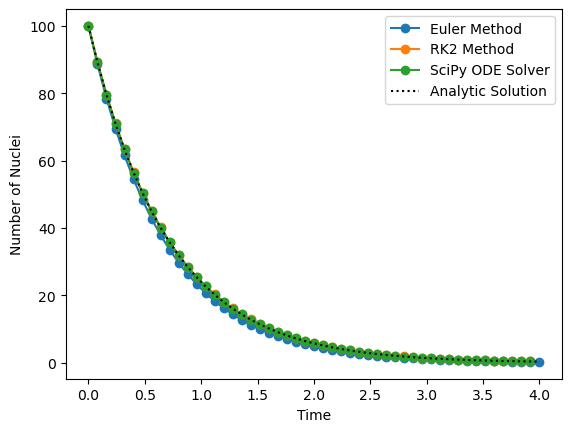

In [20]:
# parameters
tau = 0.7       # mean lifetime
N0 = 100.0      # initial number of nuclei
tmin = 0.0      # initial time
tmax = 4.0      # final time
nts = 50

# part b)
t_euler, N_euler = Euler_solver(N0, tmin, tmax, nts, decay_deriv)
t_rk2, N_rk2 = RK2_Solver(N0, tmin, tmax, nts, decay_deriv)
t_scipy, N_scipy = diffeq_solver_from_scipy(N0, tmin, tmax, nts, decay_deriv)
plt.plot(t_euler, N_euler, 'o-', label="Euler Method")
plt.plot(t_rk2, N_rk2, 'o-', label="RK2 Method")
plt.plot(t_scipy, N_scipy, 'o-', label="SciPy ODE Solver")
plt.plot(t_euler, N0*np.exp(-t_euler/tau), 'k:', label="Analytic Solution")       #t_euler = t_rk2 = t_scipy but its easier to separate them since the functions return t and N
plt.xlabel('Time')
plt.ylabel('Number of Nuclei')
plt.legend()
plt.show()

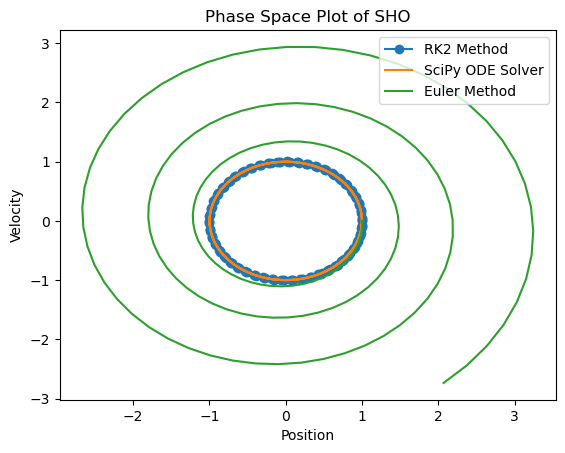

In [15]:
# Same thing except SHO instead of decay
# SHO Derivative

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def SHO_deriv(x_array, t):
    x, v = x_array
    dxdt = v
    dvdt = -k/m * x
    return [dxdt, dvdt]

# SHO functions
def SHO_solver_RK2(x0, v0, tmin, tmax, nts, SHO_deriv):
    x_array = np.zeros(nts)                                                     # array to hold position
    v_array = np.zeros(nts)                                                     # array to hold velocity
    t_array = np.linspace(tmin, tmax, nts, endpoint=False)                      # array holds the time points 
    dt = t_array[1] - t_array[0]                                                # dt = time step length  
    x_array[0] = x0                                                             # Initial position
    v_array[0] = v0                                                             # Initial velocity
    for it in range(0, len(t_array)-1 ):                                        # loop over time steps
        t  = t_array[it]                                                        
        x_h = x_array[it] + (dt/2 * SHO_deriv([x_array[it], v_array[it]], t)[0])                # sub-step 1 for RK2
        v_h = v_array[it] + (dt/2 * SHO_deriv([x_array[it], v_array[it]], t)[1])                # sub-step 1 for RK2
        x_array[it+1] = x_array[it] + (dt * SHO_deriv([x_h, v_h], t + dt/2)[0])         # sub-step 2 for RK2
        v_array[it+1] = v_array[it] + (dt * SHO_deriv([x_h, v_h], t + dt/2)[1])         # sub-step 2 for RK2
    return t_array, x_array, v_array

def SHO_solver_ODEINT(x0, v0, tmin, tmax, nts, SHO_deriv):
    t = np.linspace(tmin, tmax, nts, endpoint=False)  
    x_v_array = odeint(SHO_deriv, [x0, v0], t)
    x_array = x_v_array[:, 0]
    v_array = x_v_array[:, 1]
    return t, x_array, v_array

def SHO_solver_Euler(x0, v0, tmin, tmax, nts, SHO_deriv):
    x_array = np.zeros(nts)                           
    v_array = np.zeros(nts)                           
    t_array = np.linspace(tmin, tmax, nts, endpoint=False)
    dt = t_array[1] - t_array[0]                        
    x_array[0] = x0                                     
    v_array[0] = v0                                     
    
    for it in range(0, nts-1):
        x_array[it+1] = x_array[it] + dt * SHO_deriv([x_array[it], v_array[it]], t_array[it])[0]
        v_array[it+1] = v_array[it] + dt * SHO_deriv([x_array[it], v_array[it]], t_array[it])[1]
    
    return t_array, x_array, v_array

# parameters for SHO
m = 1.0
k = 1.0
x0 = 1.0
v0 = 0.0
tmin = 0.0
tmax = 20.0
nts = 160
t_rk2, x_rk2, v_rk2 = SHO_solver_RK2(x0, v0, tmin, tmax, nts, SHO_deriv)
t_odeint, x_odeint, v_odeint = SHO_solver_ODEINT(x0, v0, tmin, tmax, nts, SHO_deriv)
t_euler, x_euler, v_euler = SHO_solver_Euler(x0, v0, tmin, tmax, nts, SHO_deriv)
plt.plot(x_rk2, v_rk2, '-o', label="RK2 Method")
plt.plot(x_odeint, v_odeint, label="SciPy ODE Solver")
plt.plot(x_euler, v_euler, label="Euler Method")
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title('Phase Space Plot of SHO')
plt.legend()
plt.show()


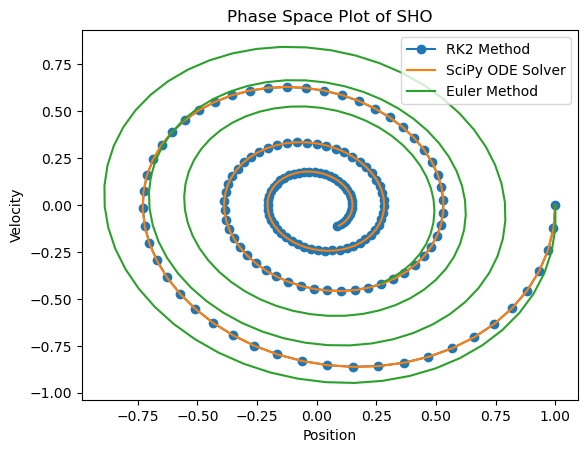

In [16]:
# now with linear damping term
def SHO_deriv_damped(x_array, t):
    x, v = x_array
    dxdt = v
    dvdt = -k/m * x - b/m * v
    return [dxdt, dvdt]

b=0.2

t_rk2, x_rk2, v_rk2 = SHO_solver_RK2(x0, v0, tmin, tmax, nts, SHO_deriv_damped)
t_odeint, x_odeint, v_odeint = SHO_solver_ODEINT(x0, v0, tmin, tmax, nts, SHO_deriv_damped)
t_euler, x_euler, v_euler = SHO_solver_Euler(x0, v0, tmin, tmax, nts, SHO_deriv_damped)
plt.plot(x_rk2, v_rk2, '-o', label="RK2 Method")
plt.plot(x_odeint, v_odeint, label="SciPy ODE Solver")
plt.plot(x_euler, v_euler, label="Euler Method")
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title('Phase Space Plot of SHO')
plt.legend()
plt.show()

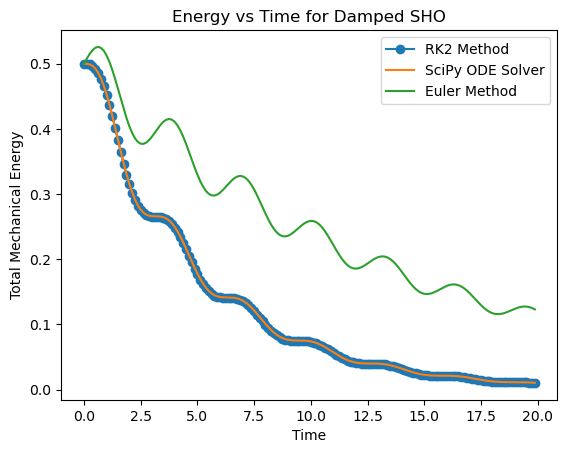

In [24]:
# How does the total mechanical energy (T+V) change over time with different solvers?

def H(x, v):
    T = 0.5 * m * v**2
    V = 0.5 * k * x**2
    return T + V

nts = 40

H_rk2 = H(x_rk2, v_rk2)
H_odeint = H(x_odeint, v_odeint)
H_euler = H(x_euler, v_euler)
plt.plot(t_rk2, H_rk2, '-o', label="RK2 Method")
plt.plot(t_odeint, H_odeint, label="SciPy ODE Solver")
plt.plot(t_euler, H_euler, label="Euler Method")
plt.xlabel('Time')
plt.ylabel('Total Mechanical Energy')
plt.title('Energy vs Time for Damped SHO')
plt.legend()
plt.show()

In [ ]:
# Verlet and RK4 methods

import numpy as np
import matplotlib.pyplot as plt
# import rk4 and verlet from scipy
from scipy.integrate import solve_ivp
from scipy.integrate import RK45

def verlet_solver(x0, v0, tmin, tmax, nts, SHO_deriv):
    x_array = np.zeros(nts)                                                     # array to hold position
    v_array = np.zeros(nts)                                                     # array to hold velocity
    t_array = np.linspace(tmin, tmax, nts, endpoint=False)                      # array holds the time points 
    dt = t_array[1] - t_array[0]                                                # dt = time step length  
    x_array[0] = x0                                                             # Initial position
    v_array[0] = v0                                                             # Initial velocity
    for it in range(0, len(t_array)-1 ):                                        # loop over time steps
        # Algorithm for Verlet method that I need to learn

    return t_array, x_array, v_array

def rk4_solver(x0, v0, tmin, tmax, nts, SHO_deriv):
    x_array = np.zeros(nts)                                                     # array to hold position
    v_array = np.zeros(nts)                                                     # array to hold velocity
    t_array = np.linspace(tmin, tmax, nts, endpoint=False)                      # array holds the time points 
    dt = t_array[1] - t_array[0]                                                # dt = time step length  
    x_array[0] = x0                                                             # Initial position
    v_array[0] = v0                                                             # Initial velocity
    for it in range(0, len(t_array)-1 ):                                        # loop over time steps
        # Algorithm for RK4 that I need to learn

    return t_array, x_array, v_array

t_rk4, x_rk4, v_rk4 = rk4_solver(x0, v0, tmin, tmax, nts, SHO_deriv)
t_verlet, x_verlet, v_verlet = verlet_solver(x0, v0, tmin, tmax, nts, SHO_deriv)
plt.plot(x_rk4, v_rk4, '-o', label="RK4 Method")
plt.plot(x_verlet, v_verlet, '-o', label="Verlet Method")
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title('Phase Space Plot of SHO')
plt.legend()
plt.show()



IndentationError: expected an indented block (268152069.py, line 18)